In [1]:
# --------------------------- PHASE-1: DATA-DRIVEN SYMPTOM MODEL TRAINING ---------------------------

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import pandas as pd
import numpy as np
from tqdm import tqdm

# ------------------- DEVICE -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------- DATA TRANSFORMS -------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ------------------- DATASET PATHS -------------------
data_dir = '/kaggle/input/rose-aug/Augmented_dataset'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

# ------------------- DATA LOADERS -------------------
batch_size = 16
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Classes:", class_names)

# ------------------- MODEL -------------------
# DenseNet121 pretrained
model = models.densenet121(pretrained=True)
# Replace classifier with 4-class classifier
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 4)
model = model.to(device)

# ------------------- LOSS AND OPTIMIZER -------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ------------------- EARLY STOPPING PARAMETERS -------------------
patience = 10
best_val_loss = float('inf')
counter = 0
num_epochs = 100

# ------------------- TRAINING LOOP -------------------
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'symptom_model.pth')
        print("Saved best model")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ------------------- EXTRACT FEATURE-BASED SYMPTOM VECTORS -------------------
# Use penultimate layer outputs as data-driven "symptom activations"
from torch.nn import functional as F

# Hook to capture penultimate layer
features_list = []

def hook_fn(module, input, output):
    features_list.append(output.detach())

# Register hook on the last batchnorm before classifier
hook_handle = model.features.norm5.register_forward_hook(hook_fn)

model.eval()
symptom_dict = {"class_name": [], "feature1": [], "feature2": [], "feature3": [], "feature4": []}

with torch.no_grad():
    for cls_idx, cls_name in enumerate(class_names):
        # Get indices of images of this class
        cls_indices = [i for i,l in enumerate(train_dataset.targets) if l==cls_idx]
        loader = DataLoader(torch.utils.data.Subset(train_dataset, cls_indices), batch_size=16, shuffle=False)
        mean_activation = np.zeros(4)  # 4-d vector for "symptom"
        count = 0
        for imgs, _ in loader:
            imgs = imgs.to(device)
            features_list.clear()
            outputs = model(imgs)
            # Average over batch and reduce to 4-d via classifier weights
            feats = features_list[0].mean(dim=[2,3]).cpu()  # global avg pool
            w = model.classifier.weight[:, :feats.shape[1]].cpu()
            activations = F.linear(feats, w)  # linear combination -> 4-d
            mean_activation += activations.sum(dim=0).numpy()
            count += imgs.size(0)
        mean_activation /= count
        symptom_dict["class_name"].append(cls_name)
        symptom_dict["feature1"].append(mean_activation[0])
        symptom_dict["feature2"].append(mean_activation[1])
        symptom_dict["feature3"].append(mean_activation[2])
        symptom_dict["feature4"].append(mean_activation[3])

hook_handle.remove()

symptom_df = pd.DataFrame(symptom_dict)
symptom_df.to_csv("symptom_nutrient_weights.csv", index=False)
print("Saved data-driven symptom weight CSV")
print(symptom_df)


Using device: cuda
Classes: ['healthy', 'iron', 'magnesium', 'phoshorus']


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 172MB/s]
Epoch 1/100 [Training]: 100%|██████████| 263/263 [00:29<00:00,  8.84it/s]


Epoch 1: Train Loss=0.1558, Val Loss=0.0138
Saved best model


Epoch 2/100 [Training]: 100%|██████████| 263/263 [00:28<00:00,  9.12it/s]


Epoch 2: Train Loss=0.0274, Val Loss=0.0101
Saved best model


...

Epoch 30: Train Loss=0.0013, Val Loss=0.0197


Epoch 31/100 [Training]: 100%|██████████| 263/263 [00:28<00:00,  9.16it/s]


Epoch 31: Train Loss=0.0007, Val Loss=0.0029


Epoch 32/100 [Training]: 100%|██████████| 263/263 [00:28<00:00,  9.13it/s]


Epoch 32: Train Loss=0.0010, Val Loss=0.0050
Early stopping at epoch 32
Saved data-driven symptom weight CSV
  class_name  feature1   feature2  feature3  feature4
0    healthy  9.259541  -7.204908 -4.783099 -3.261909
1       iron -4.814395  12.834130 -8.682220 -7.244993
2  magnesium -4.589095  -4.273058  9.305691 -5.927994
3  phoshorus -8.089556  -5.938646 -3.292620  9.423291


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


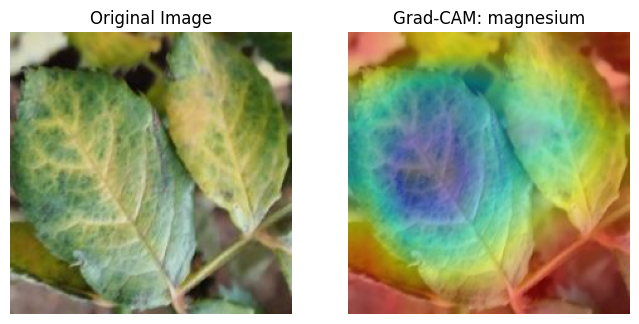

Predicted Class: magnesium
Symptom Activations: [4.6000889e-04 4.7315361e-08 9.9953985e-01 3.5543028e-08]
Class Scores: [-0.36526759 -0.48872     0.73309754 -0.23288399]


In [4]:
# --------------------------- PHASE-2: NUTRIENT PREDICTION + CORRECT GRAD-CAM ---------------------------

import torch
import torch.nn as nn
from torchvision import models, transforms
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# ------------------- DEVICE -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------- PARAMETERS -------------------
model_path = "symptom_model.pth"
csv_path = "symptom_nutrient_weights.csv"
image_path = "/kaggle/input/rose-aug/Augmented_dataset/test/magnesium/magnesium_0002.jpg"  # Example test image
eps_healthy = 1e-3  # Threshold to detect healthy (optional)

# ------------------- IMAGE TRANSFORM -------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ------------------- LOAD MODEL -------------------
model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 4)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# ------------------- LOAD CSV -------------------
symptom_df = pd.read_csv(csv_path)
classes = symptom_df['class_name'].tolist()
class_vectors = symptom_df.iloc[:,1:].values  # 4-d feature vectors

# ------------------- COSINE SIMILARITY -------------------
def cosine_similarity(vec1, vec2):
    vec1 = vec1 / np.linalg.norm(vec1)
    vec2 = vec2 / np.linalg.norm(vec2)
    return np.dot(vec1, vec2)

# ------------------- GRAD-CAM FUNCTION -------------------
def generate_gradcam(model, img_tensor, target_class=None):
    features = []
    gradients = []

    def forward_hook(module, input, output):
        features.append(output)
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Register hooks on last convolutional layer
    handle_forward = model.features.register_forward_hook(forward_hook)
    handle_backward = model.features.register_backward_hook(backward_hook)

    img_tensor = img_tensor.unsqueeze(0).to(device)
    model.zero_grad()
    output = model(img_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()
    loss = output[0,target_class]
    loss.backward()

    fmap = features[0][0].cpu().detach().numpy()      # feature map
    grads = gradients[0][0].cpu().detach().numpy()    # gradient map

    weights = np.mean(grads, axis=(1,2))              # channel-wise importance
    cam = np.zeros(fmap.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmap[i]
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224,224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize
    handle_forward.remove()
    handle_backward.remove()
    return cam

# ------------------- PREDICTION FUNCTION -------------------
def predict_nutrient(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img)

    # Get model output
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        symptom_activation = F.softmax(output, dim=1).cpu().numpy()[0]  # 4-d

    # Compare with CSV vectors
    scores = []
    for vec in class_vectors:
        scores.append(cosine_similarity(symptom_activation, vec))
    scores = np.array(scores)
    pred_idx = scores.argmax()
    pred_class = classes[pred_idx]

    # Optional: detect healthy if very low activation
    if symptom_activation.max() < eps_healthy:
        pred_class = "Healthy"

    # Generate Grad-CAM
    cam = generate_gradcam(model, img_tensor, target_class=pred_idx)
    cam_img = np.array(img.resize((224,224)))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(cam_img, 0.6, heatmap, 0.4, 0)

    # Display
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title(f"Grad-CAM: {pred_class}")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

    return pred_class, symptom_activation, scores

# ------------------- TEST -------------------
pred_class, symptom_activation, scores = predict_nutrient(image_path)
print("Predicted Class:", pred_class)
print("Symptom Activations:", symptom_activation)
print("Class Scores:", scores)


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


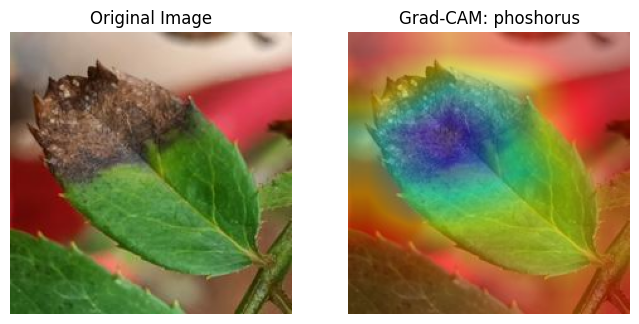

Predicted Class: phoshorus
Symptom Activations: [5.7321571e-08 1.9550663e-07 1.2883409e-06 9.9999845e-01]
Class Scores: [-0.24932262 -0.40771539 -0.46710957  0.66574764]


In [6]:
# --------------------------- PHASE-2: NUTRIENT PREDICTION + CORRECT GRAD-CAM ---------------------------

import torch
import torch.nn as nn
from torchvision import models, transforms
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# ------------------- DEVICE -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------- PARAMETERS -------------------
model_path = "symptom_model.pth"
csv_path = "symptom_nutrient_weights.csv"
image_path = "/kaggle/input/rose-aug/Augmented_dataset/test/phoshorus/phoshorus_0006.jpg"  # Example test image
eps_healthy = 1e-3  # Threshold to detect healthy (optional)

# ------------------- IMAGE TRANSFORM -------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ------------------- LOAD MODEL -------------------
model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 4)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# ------------------- LOAD CSV -------------------
symptom_df = pd.read_csv(csv_path)
classes = symptom_df['class_name'].tolist()
class_vectors = symptom_df.iloc[:,1:].values  # 4-d feature vectors

# ------------------- COSINE SIMILARITY -------------------
def cosine_similarity(vec1, vec2):
    vec1 = vec1 / np.linalg.norm(vec1)
    vec2 = vec2 / np.linalg.norm(vec2)
    return np.dot(vec1, vec2)

# ------------------- GRAD-CAM FUNCTION -------------------
def generate_gradcam(model, img_tensor, target_class=None):
    features = []
    gradients = []

    def forward_hook(module, input, output):
        features.append(output)
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Register hooks on last convolutional layer
    handle_forward = model.features.register_forward_hook(forward_hook)
    handle_backward = model.features.register_backward_hook(backward_hook)

    img_tensor = img_tensor.unsqueeze(0).to(device)
    model.zero_grad()
    output = model(img_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()
    loss = output[0,target_class]
    loss.backward()

    fmap = features[0][0].cpu().detach().numpy()      # feature map
    grads = gradients[0][0].cpu().detach().numpy()    # gradient map

    weights = np.mean(grads, axis=(1,2))              # channel-wise importance
    cam = np.zeros(fmap.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmap[i]
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224,224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize
    handle_forward.remove()
    handle_backward.remove()
    return cam

# ------------------- PREDICTION FUNCTION -------------------
def predict_nutrient(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img)

    # Get model output
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        symptom_activation = F.softmax(output, dim=1).cpu().numpy()[0]  # 4-d

    # Compare with CSV vectors
    scores = []
    for vec in class_vectors:
        scores.append(cosine_similarity(symptom_activation, vec))
    scores = np.array(scores)
    pred_idx = scores.argmax()
    pred_class = classes[pred_idx]

    # Optional: detect healthy if very low activation
    if symptom_activation.max() < eps_healthy:
        pred_class = "Healthy"

    # Generate Grad-CAM
    cam = generate_gradcam(model, img_tensor, target_class=pred_idx)
    cam_img = np.array(img.resize((224,224)))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(cam_img, 0.6, heatmap, 0.4, 0)

    # Display
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title(f"Grad-CAM: {pred_class}")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

    return pred_class, symptom_activation, scores

# ------------------- TEST -------------------
pred_class, symptom_activation, scores = predict_nutrient(image_path)
print("Predicted Class:", pred_class)
print("Symptom Activations:", symptom_activation)
print("Class Scores:", scores)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        23
        iron       1.00      1.00      1.00        23
   magnesium       1.00      1.00      1.00        23
   phoshorus       1.00      1.00      1.00        23

    accuracy                           1.00        92
   macro avg       1.00      1.00      1.00        92
weighted avg       1.00      1.00      1.00        92



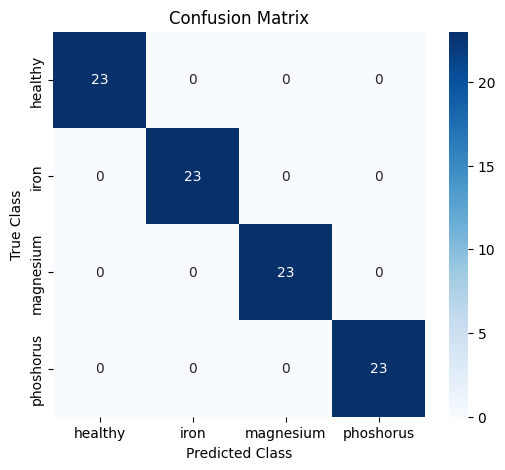

In [14]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# ------------------- 1. DEVICE -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------- 2. DATASET & DATALOADER -------------------
data_dir = "/kaggle/input/rose-aug/Augmented_dataset"
batch_size = 16

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = test_dataset.classes  # ['Healthy','Iron','Magnesium','Phosphorus']

# ------------------- 3. LOAD MODEL -------------------
model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 4)
model.load_state_dict(torch.load("symptom_model.pth", map_location=device))
model.to(device)
model.eval()

# ------------------- 4. EVALUATION -------------------
criterion = nn.CrossEntropyLoss()
all_labels = []
all_preds = []
running_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# ------------------- 5. METRICS -------------------
# Overall accuracy
accuracy = np.mean(np.array(all_labels) == np.array(all_preds))
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()


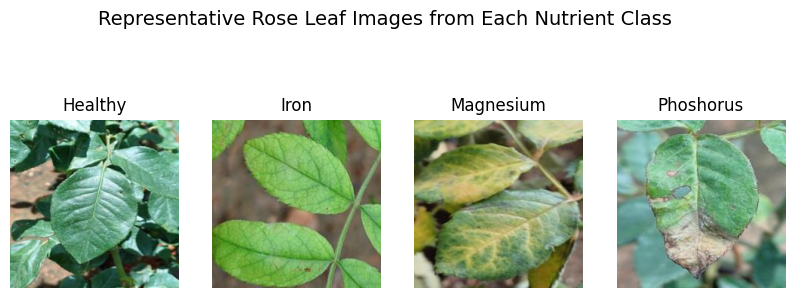

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Dataset base path
base_path = "/kaggle/input/rose-aug/Augmented_dataset/train"

classes = ["healthy", "iron", "magnesium", "phoshorus"]

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_path, cls)
    
    # Pick the first image in each class folder
    img_name = sorted(os.listdir(cls_path))[0]
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(cls.capitalize())
    plt.axis("off")

plt.suptitle("Representative Rose Leaf Images from Each Nutrient Class", fontsize=14)
plt.show()
